---
title: "Aggregate Statistics Comparisons"
date: 2025-04-12
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

To further validate our catalog, in addition to ensuring we properly identified known storms presented in case studies, we also check that we are able to reproduce AR count statistics, by year and by geographic location, reported in the literature.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd
import xarray as xr
import seaborn as sns
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

from artools.attribute_utils import *
from artools.loading_utils import *

In [7]:
# loading up the ais and catalogs
ais_mask = load_ais('../../input_data/antarctic_masks/')
load_path = '../../catalogs/official/epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5'
df = pd.read_hdf(load_path)
landfalling_df = df[df.is_landfalling]

In [11]:
# add in landfalling times and durations
landfalling_df['landfalling_duration'] = landfalling_df['data_array'].apply(compute_duration, ais_da=ais_mask)
landfalling_df['landfalling_start_date'] = landfalling_df['data_array'].apply(add_start_date, ais_da=ais_mask)
landfalling_df['landfalling_end_date'] = landfalling_df['data_array'].apply(add_end_date, ais_da=ais_mask)

## Histograms of Landfalling Locations

We first reproduce Figure 1b of [Synoptic and planetary-scale dynamics modulate Antarctic atmospheric river precipitation intensity](https://doi.org/10.1038/s43247-024-01307-9) by Baiman et al.

:::{figure} attachment:c9cb2c97-9eff-41f1-b14d-6215152abf12.png
:width: 300px
The original figure from Baiman et al. (2024), showing the distribution of longitudinal centers of ARs where they intersect with $55^{\circ}$ S latitude.
:::
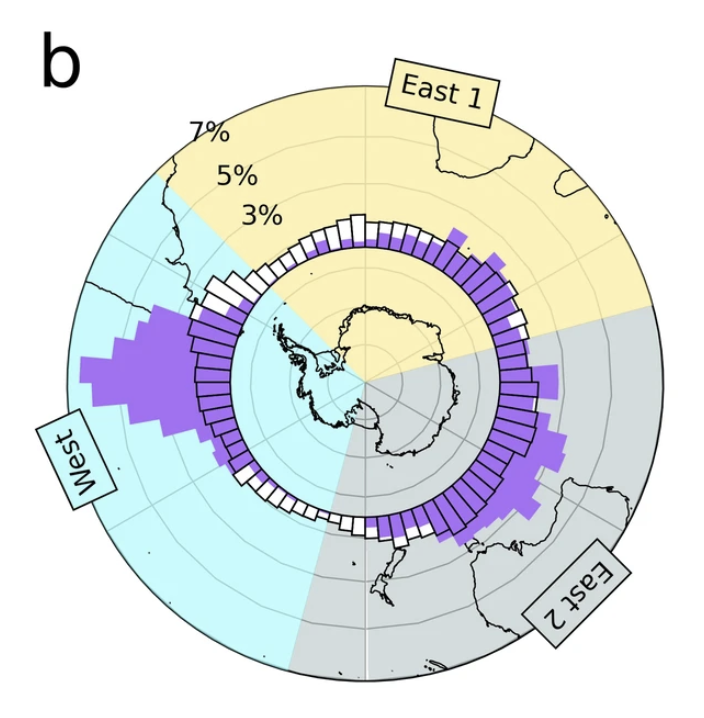

To make this plot, we first write a function that, given an AR's data array, finds all of the average longitudes across the $55^{\circ}$ S latitude for each time step the AR passes through.

In [27]:
def get_avg_lons(da, target_lat=-55):

    da_lat = da.sel(lat=target_lat, method='nearest')
    mask = da_lat.astype(float)
    counts = mask.sum(dim='lon')
    
    # Convert coordinates to radians and calculate Cartesian
    lat_rad = np.radians(da_lat.lat)
    lon_rad = np.radians(da_lat.lon)
    x = np.cos(lat_rad)*np.cos(lon_rad)
    y = np.cos(lat_rad)*np.sin(lon_rad)
    
    # Calculate the average x and y only where the mask == 1
    avg_x = (x*mask).sum(dim='lon')/counts
    avg_y = (y*mask).sum(dim='lon')/counts
    
    avg_lon_rad = np.arctan2(avg_y, avg_x)
    avg_lon_deg = np.degrees(avg_lon_rad)
    
    avg_lon_deg = avg_lon_deg.where(counts > 0, np.nan)
    
    return avg_lon_deg

Then, we apply this function to all of the ARs and organize the average longitudes into a list, such that we have a list of average longitudes at each AR timestep.

In [29]:
mean_lons_list = [get_circular_mean_lon_at_lat(ar.data_array, target_lat=-55) for index, ar in landfalling_df.iterrows()]
all_mean_lons = np.concatenate([m.values for m in mean_lons_list])
clean_mean_lons = all_mean_lons[~np.isnan(all_mean_lons)]

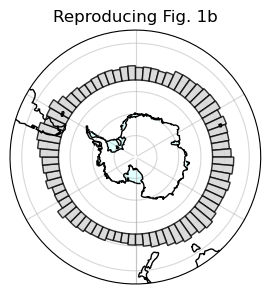

In [55]:
fig = plt.figure(figsize=(11, 4))
ax1 = plt.subplot(131, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.))

ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m', edgecolor='none', facecolor='lightcyan')
ax1.add_feature(ice_shelf_poly, linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m', edgecolor='black', facecolor='none')
ax1.add_feature(ice_shelf_line, linewidth=1, zorder=13)
ax1.coastlines(resolution='110m', linewidth=1, zorder=32)

# Expanding the extent slightly to make room for the histogram bars
ax1.set_extent([-180, 180, -90, -35], ccrs.PlateCarree())
ax1.set_title('Reproducing Fig. 1b')
ax1.grid(True, linestyle='--', color='gray', alpha=0.5)

 # Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax1.set_boundary(circle, transform=ax1.transAxes)
ax1.gridlines(alpha=0.5, zorder=33)

# Define histogram parameters
num_bins = 72
counts, bin_edges = np.histogram(clean_mean_lons, bins=num_bins, range=(-180, 180), density=True)

# define histogram heights relative to a maximum latitude
baseline_lat = -55
max_lat_stretch = 10 
scaled_heights = (counts / counts.max()) * max_lat_stretch

for i in range(len(counts)):
    # if no intersections with 55 S
    if counts[i] == 0:
        continue
    
    # Left and right longitudes for this bin
    lon1 = bin_edges[i]
    lon2 = bin_edges[i+1]
    
    # Bottom and top latitudes for this bin
    lat_bottom = baseline_lat
    lat_top = baseline_lat + scaled_heights[i] # Adding a positive number moves it North
    
    # Create vertices for the polygon. 
    # We use np.linspace to add intermediate points along the top and bottom 
    # edges so Cartopy bends the polygon smoothly along the latitude curves.
    lons = np.linspace(lon1, lon2, 10)
    
    # Top edge coordinates (left to right)
    top_edge = np.column_stack((lons, np.full_like(lons, lat_top)))
    
    # Bottom edge coordinates (right to left to close the polygon loop)
    bottom_edge = np.column_stack((lons[::-1], np.full_like(lons, lat_bottom)))
    
    # Stack them to form the closed polygon perimeter
    verts = np.vstack((top_edge, bottom_edge))
    
    # Create the patch and add it to the map
    # Using transform=ccrs.PlateCarree() is the crucial step that forces 
    # Cartopy to project our standard coordinates onto the polar map.
    poly = Polygon(verts, facecolor='lightgray', edgecolor='black', 
                   transform=ccrs.PlateCarree(), alpha=0.8, zorder=10)
    ax1.add_patch(poly)

fig.savefig('../../output/plots/reproduce_longitudinal_hist.png', dpi=300)

We see similarities in the distribution of average longitudes between our plot and the original. For instance, we see higher counts around longitudes near the Antarctic Peninsula, steady amounts across East Antarctic longitudes, and the lowest counts near the Ross Ice Shelf.

### Durations and Counts in West Antarctica

Next, we seek to reproduce various statistics and figures from [Climatology and surface impacts of atmospheric rivers on West Antarctica](https://doi.org/10.5194/tc-17-865-2023) by Maclennan et al., which conducts an extensive analysis of AR landfall counts and durations in Marie Byrd Land and the Amnudsen Sea Embayment.

We first define two functions, one which determines if an AR falls at all within a spatial bounding box, and also for how many hours the storm spends in the the bounding box.

In [56]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & 
                         (da.lat >= lat_low) & 
                         (da.lon <= lon_high) & 
                         (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & 
                           (da.lat >= lat_low) & 
                           (da.lon <= lon_high) & 
                           (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration

We count a storm as making landfall in Marie Byrd Land/Amundsen Sea Embayment if it intsersects $72.5^{\circ}$ S, between $150^{\circ}$ W and $80^{\circ}$ W. The duration of landfall is counted as the elapsed time between the first time it passes through the region defined by these longitudes and between $80^{\circ}$ S and $72.5^{\circ}$ S, and the last. We choose the coordinate $72.5^{\circ}$ S beceause this arc roughly corresponds to the coastline, and $150^{\circ}$ W and $80^{\circ}$ W as this range roughly covers the geographic region of interest. The original paper uses ARs defined up to $80^{\circ}$ S.

In [59]:
landfalling_df['in_MBL_ASE'] = landfalling_df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))
mbl_ase_storms = landfalling_df[landfalling_df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))

We first seek to reproduce Figures 3a and 3b from Maclennan et al. (2023).

:::{figure} attachment:d35a5c1d-0e8a-44db-8423-11b732fc9cd6.png
:width: 500px
Figure 3a.
:::
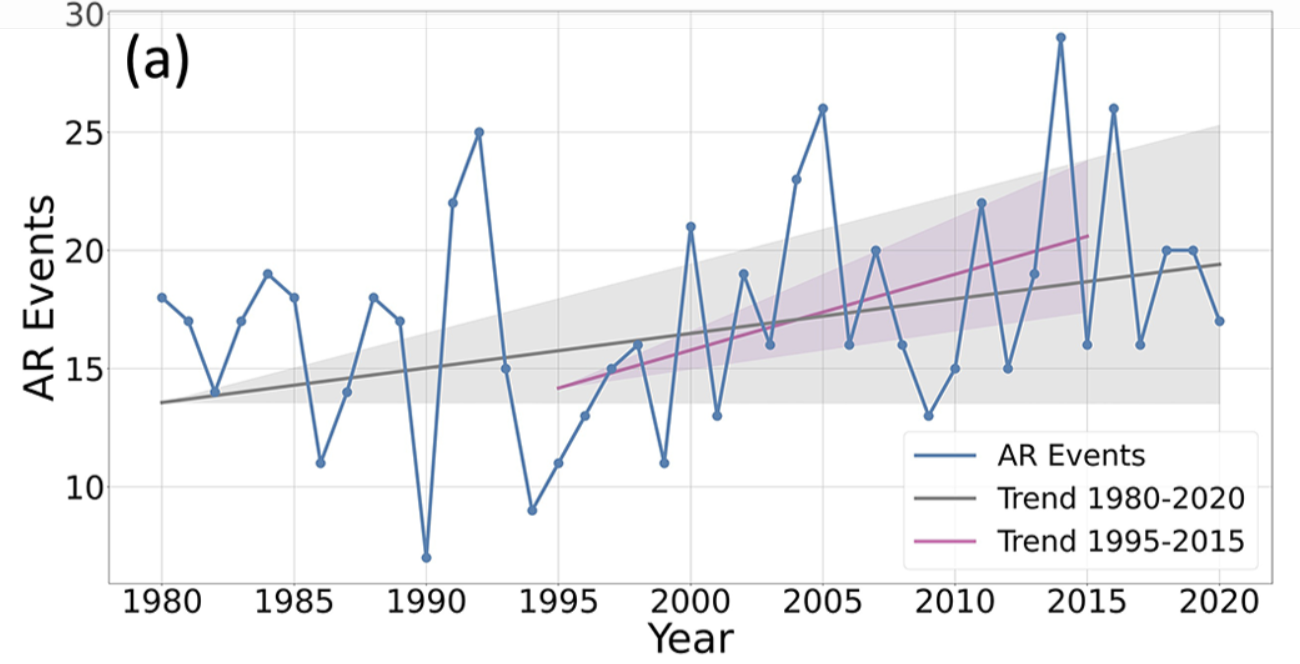

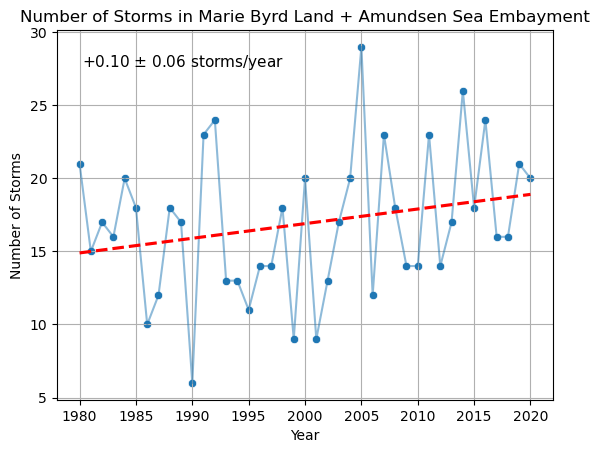

In [83]:
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year, as_index=False).size()
num_storms = num_storms[num_storms.landfalling_start_date <= 2020]
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

x = num_storms['landfalling_start_date']
y = num_storms['size']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.lineplot(data=num_storms, x='landfalling_start_date', y='size', alpha=0.5)
sns.scatterplot(data=num_storms, x='landfalling_start_date', y='size')
sns.regplot(data=num_storms, x='landfalling_start_date', y='size', 
            scatter=False, color='red', line_kws={'linestyle': '--'}, ci=None)

plt.title('Number of Storms in Marie Byrd Land + Amundsen Sea Embayment')
plt.xlabel('Year')
plt.ylabel('Number of Storms')
text_box = f"+{slope:.2f} $\\pm$ {std_err:.2f} storms/year"
plt.text(0.05, 0.90, text_box, 
         transform=plt.gca().transAxes, 
         fontsize=11, color='black')
plt.grid()

plt.show()

We find several similarities between our reproduction of the plot and the original, including downward spikes at 1990, 2001, and 2009, and upward spikes in 1992, 2005, and 2014. Further, we find an upward trend of $0.10 \pm 0.06$ additional storms per year and the original paper reports $0.12 \pm 0.06$.

Further, the original paper reports a yearly average of $17 \pm 5$ AR events during this period. Rounding to the nearest integer, we compute the same average and standard deviation.

In [87]:
float(num_storms['size'].mean())

16.902439024390244

In [88]:
float(num_storms['size'].std())

4.968927842345774

Lastly, we seek to reproduce Figure 3b.

:::{figure} attachment:a31d8112-49f1-4c0b-a735-db74ae514af8.png
:width: 500px
Figure 3b.
:::
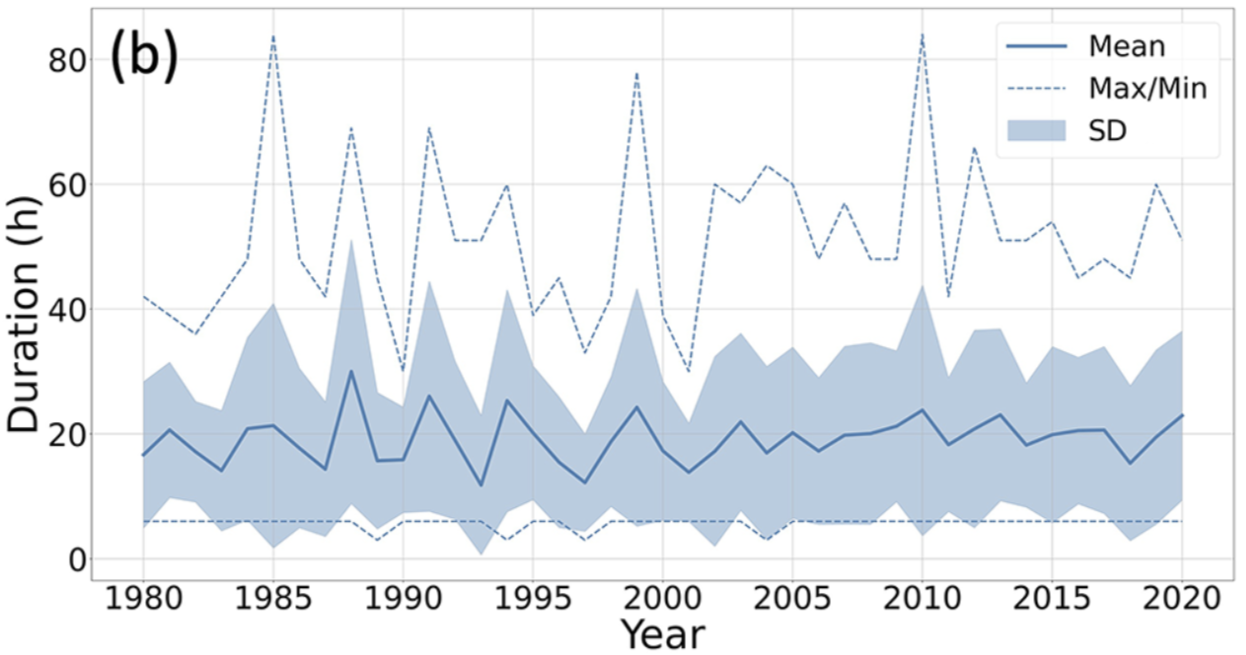

In [102]:
mbl_ase_storms_mean_durations = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
mbl_ase_storms_sd_durations = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year).duration_MBL_ASE.std()/np.timedelta64(1, 'h')
mbl_ase_storms_plussd_durations = mbl_ase_storms_mean_durations + mbl_ase_storms_sd_durations
mbl_ase_storms_minussd_durations = mbl_ase_storms_mean_durations - mbl_ase_storms_sd_durations
mbl_ase_storms_max_durations = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year).duration_MBL_ASE.max()/np.timedelta64(1, 'h')
mbl_ase_storms_min_durations = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year).duration_MBL_ASE.min()/np.timedelta64(1, 'h')

durations_df = pd.concat({'mean': mbl_ase_storms_mean_durations, 
                          'plus_sd':mbl_ase_storms_plussd_durations, 
                          'minus_sd': mbl_ase_storms_minussd_durations, 
                          'max': mbl_ase_storms_max_durations, 
                          'min': mbl_ase_storms_min_durations}, axis=1)
durations_df = durations_df.reset_index()

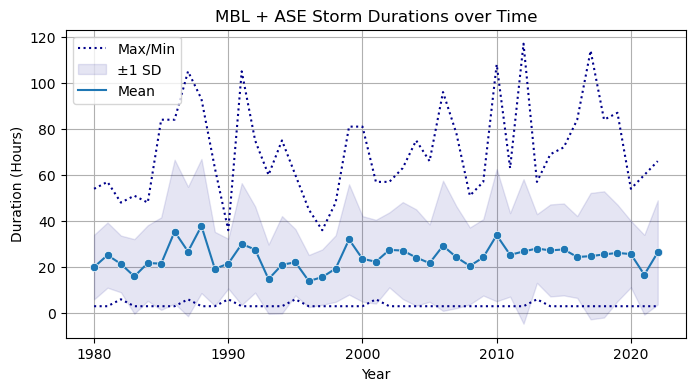

In [107]:
plt.figure(figsize=(8, 4))
plt.grid(zorder=0)
sns.lineplot(data=durations_df, x='landfalling_start_date', y='max', color='darkblue', label='Max/Min', linestyle='dotted')
sns.lineplot(data=durations_df, x='landfalling_start_date', y='min', color='darkblue', linestyle='dotted')

plt.fill_between(
    durations_df['landfalling_start_date'], 
    durations_df['minus_sd'], 
    durations_df['plus_sd'], 
    color='darkblue', 
    alpha=0.1, 
    label='±1 SD',
    zorder=2
)

sns.lineplot(data=durations_df, x='landfalling_start_date', y='mean', label='Mean', zorder=3)
sns.scatterplot(data=durations_df, x='landfalling_start_date', y='mean', zorder=4)

plt.title('MBL + ASE Storm Durations over Time')
plt.xlabel('Year')
plt.ylabel('Duration (Hours)')
plt.legend(loc='upper left')

plt.show()

We see similarities with the original figure, including max duration upward spikes at 1987, 1991, 2010, and 2012, and a notable downward spike at 1990.